In [2]:
import requests
import pandas as pd

def get_klines(symbol="BTCUSDT", interval="5m", limit=1000):
    url = "https://api.binance.com/api/v3/klines"
    params = {"symbol": symbol, "interval": interval, "limit": limit}
    response = requests.get(url, params=params)
    data = response.json()
    return data

raw_data = get_klines()
print(len(raw_data))
print(raw_data[0])


1000
[1782420000000, '59432.00000000', '59522.01000000', '59414.04000000', '59522.01000000', '41.26300000', 1782420299999, '2453162.12835900', 9503, '22.40640000', '1332129.23667010', '0']


In [3]:
columns = [
    "open_time", "open", "high", "low", "close", "volume",
    "close_time", "quote_asset_volume", "num_trades",
    "taker_buy_base", "taker_buy_quote", "ignore"
]

df = pd.DataFrame(raw_data, columns=columns)
df.head()

,open_time,open,high,low,close,volume,close_time,quote_asset_volume,num_trades,taker_buy_base,taker_buy_quote,ignore
0,1782420000000,59432.00000000,59522.01000000,59414.04000000,59522.01000000,41.26300000,1782420299999,2453162.12835900,9503,22.40640000,1332129.23667010,0
1,1782420300000,59522.01000000,59522.01000000,59426.00000000,59451.45000000,39.73623000,1782420599999,2363698.82024000,7772,30.99006000,1843389.65064280,0
2,1782420600000,59451.45000000,59451.45000000,59356.09000000,59364.09000000,24.90254000,1782420899999,1479254.72586140,11540,10.71387000,636453.72596810,0
3,1782420900000,59364.10000000,59465.49000000,59344.00000000,59456.62000000,27.90503000,1782421199999,1657611.64000160,10214,15.24055000,905250.20754470,0
4,1782421200000,59456.62000000,59512.72000000,59452.01000000,59510.00000000,50.77940000,1782421499999,3020163.67914270,12874,28.73407000,1708996.53503540,0


In [4]:
# Convert price/volume columns from string to actual numbers
numeric_cols = ["open", "high", "low", "close", "volume"]
df[numeric_cols] = df[numeric_cols].astype(float)

# Convert timestamp (milliseconds) to an actual datetime
df["open_time"] = pd.to_datetime(df["open_time"], unit="ms")

# Drop columns we don't need for this project
df = df[["open_time", "open", "high", "low", "close", "volume"]]

df.head()

,open_time,open,high,low,close,volume
0,2026-06-25 20:40:00,59432.00,59522.01,59414.04,59522.01,41.26300
1,2026-06-25 20:45:00,59522.01,59522.01,59426.00,59451.45,39.73623
2,2026-06-25 20:50:00,59451.45,59451.45,59356.09,59364.09,24.90254
3,2026-06-25 20:55:00,59364.10,59465.49,59344.00,59456.62,27.90503
4,2026-06-25 21:00:00,59456.62,59512.72,59452.01,59510.00,50.77940


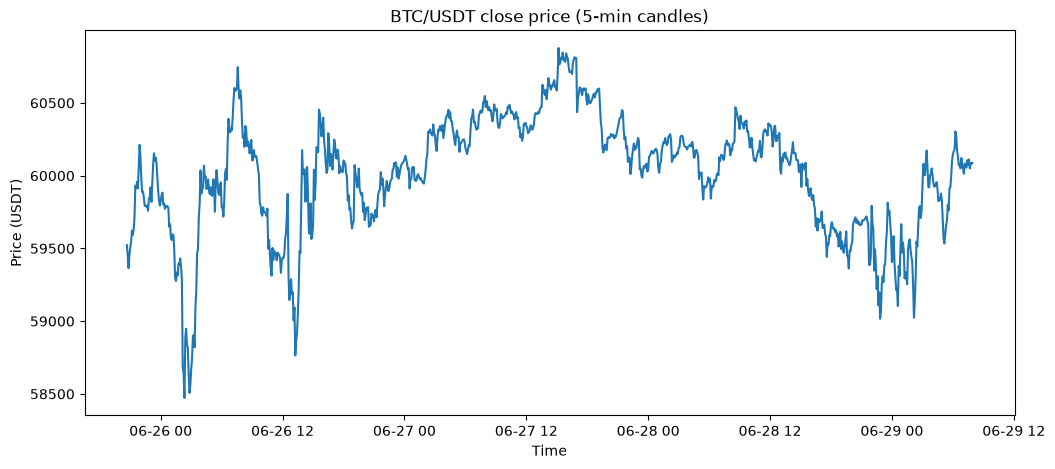

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(df["open_time"], df["close"])
plt.title("BTC/USDT close price (5-min candles)")
plt.xlabel("Time")
plt.ylabel("Price (USDT)")
plt.show()

In [6]:
import time

def get_full_history(symbol="BTCUSDT", interval="5m", days=21):
    all_candles = []
    end_time = int(time.time() * 1000)  # now, in milliseconds
    ms_per_candle = 5 * 60 * 1000        # 5 minutes in milliseconds
    candles_needed = (days * 24 * 60 * 60 * 1000) // ms_per_candle

    while len(all_candles) < candles_needed:
        url = "https://api.binance.com/api/v3/klines"
        params = {
            "symbol": symbol,
            "interval": interval,
            "limit": 1000,
            "endTime": end_time
        }
        response = requests.get(url, params=params)
        batch = response.json()

        if not batch:
            break

        all_candles = batch + all_candles
        end_time = batch[0][0] - 1  # move endTime to just before the earliest candle we got
        time.sleep(0.3)  # be polite to Binance's API, avoid rate limits

    return all_candles

full_data = get_full_history(days=21)
print(len(full_data))

7000


In [7]:
df = pd.DataFrame(full_data, columns=columns)

numeric_cols = ["open", "high", "low", "close", "volume"]
df[numeric_cols] = df[numeric_cols].astype(float)

df["open_time"] = pd.to_datetime(df["open_time"], unit="ms")
df = df[["open_time", "open", "high", "low", "close", "volume"]]

df = df.drop_duplicates(subset="open_time").reset_index(drop=True)

print(df.shape)
df.head()

(7000, 6)


,open_time,open,high,low,close,volume
0,2026-06-05 00:40:00,63862.71,63864.00,63688.00,63697.94,49.22248
1,2026-06-05 00:45:00,63697.94,63797.71,63660.00,63748.00,66.39026
2,2026-06-05 00:50:00,63748.01,63748.01,63510.00,63524.01,80.14716
3,2026-06-05 00:55:00,63524.00,63524.00,63396.57,63426.72,51.68274
4,2026-06-05 01:00:00,63426.73,63426.73,63052.00,63070.85,155.63307


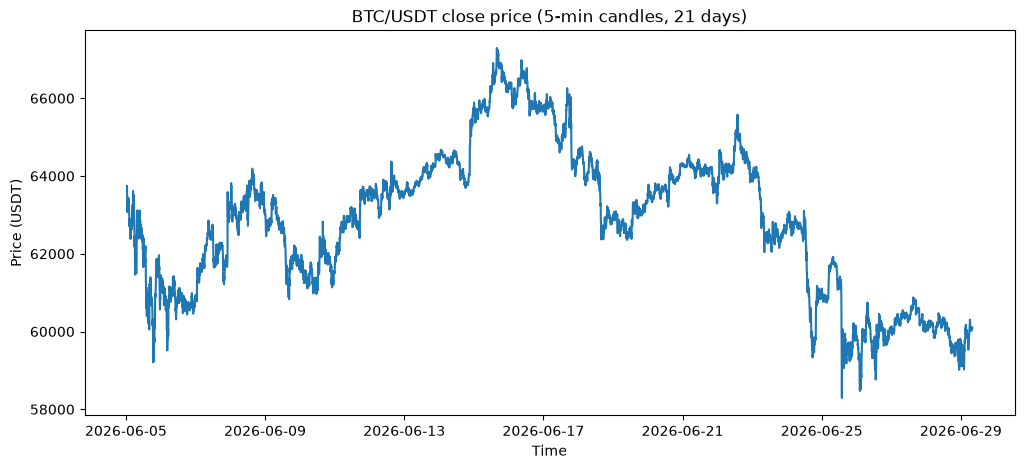

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(df["open_time"], df["close"])
plt.title("BTC/USDT close price (5-min candles, 21 days)")
plt.xlabel("Time")
plt.ylabel("Price (USDT)")
plt.show()

In [9]:
df.to_csv("btcusdt_5m.csv", index=False)
print("Saved:", df.shape)

Saved: (7000, 6)


In [10]:
df = pd.read_csv("btcusdt_5m.csv")
df["open_time"] = pd.to_datetime(df["open_time"])
df.head()

,open_time,open,high,low,close,volume
0,2026-06-05 00:40:00,63862.71,63864.00,63688.00,63697.94,49.22248
1,2026-06-05 00:45:00,63697.94,63797.71,63660.00,63748.00,66.39026
2,2026-06-05 00:50:00,63748.01,63748.01,63510.00,63524.01,80.14716
3,2026-06-05 00:55:00,63524.00,63524.00,63396.57,63426.72,51.68274
4,2026-06-05 01:00:00,63426.73,63426.73,63052.00,63070.85,155.63307


In [11]:
# 1. Returns: % change in price from N candles ago
df["return_1"] = df["close"].pct_change(1)
df["return_3"] = df["close"].pct_change(3)

# 2. Rolling volatility: how much the price has been jumping around recently
df["rolling_vol"] = df["return_1"].rolling(window=6).std()

# 3. Volume change: % change in volume vs the previous candle
df["volume_change"] = df["volume"].pct_change(1)

df[["open_time", "close", "return_1", "return_3", "rolling_vol", "volume_change"]].head(10)

,open_time,close,return_1,return_3,rolling_vol,volume_change
0,2026-06-05 00:40:00,63697.94,NaN,NaN,NaN,NaN
1,2026-06-05 00:45:00,63748.00,0.000786,NaN,NaN,0.348779
2,2026-06-05 00:50:00,63524.01,-0.003514,NaN,NaN,0.207213
3,2026-06-05 00:55:00,63426.72,-0.001532,-0.004258,NaN,-0.355152
4,2026-06-05 01:00:00,63070.85,-0.005611,-0.010622,NaN,2.011316
5,2026-06-05 01:05:00,63212.64,0.002248,-0.004902,NaN,-0.353680
6,2026-06-05 01:10:00,63361.92,0.002362,-0.001022,0.003250,-0.339518
7,2026-06-05 01:15:00,63356.00,-0.000093,0.004521,0.003179,0.102815
8,2026-06-05 01:20:00,63313.99,-0.000663,0.001603,0.002936,-0.174232
9,2026-06-05 01:25:00,63343.99,0.000474,-0.000283,0.002916,0.308160


In [12]:
# Look 3 candles into the future, compare to current close
df["future_close"] = df["close"].shift(-3)
df["label"] = (df["future_close"] > df["close"]).astype(int)

df[["open_time", "close", "future_close", "label"]].head(10)
df[["open_time", "close", "future_close", "label"]].tail(10)

,open_time,close,future_close,label
6990,2026-06-29 07:10:00,60084.00,60106.02,1
6991,2026-06-29 07:15:00,60068.00,60073.02,1
6992,2026-06-29 07:20:00,60055.25,60111.41,1
6993,2026-06-29 07:25:00,60106.02,60050.01,0
6994,2026-06-29 07:30:00,60073.02,60087.99,1
6995,2026-06-29 07:35:00,60111.41,60079.99,0
6996,2026-06-29 07:40:00,60050.01,60086.40,1
6997,2026-06-29 07:45:00,60087.99,NaN,0
6998,2026-06-29 07:50:00,60079.99,NaN,0
6999,2026-06-29 07:55:00,60086.40,NaN,0


In [13]:
# Drop rows with any NaN (from rolling features at the start, and the shifted label at the end)
df_clean = df.dropna().reset_index(drop=True)

print("Before:", df.shape)
print("After dropping NaNs:", df_clean.shape)

# Check class balance - is it roughly 50/50 up vs down?
print(df_clean["label"].value_counts())
print(df_clean["label"].value_counts(normalize=True))

Before: (7000, 12)
After dropping NaNs: (6991, 12)
label
0    3560
1    3431
Name: count, dtype: int64
label
0    0.509226
1    0.490774
Name: proportion, dtype: float64


In [14]:
split_idx = int(len(df_clean) * 0.7)

train_df = df_clean.iloc[:split_idx]
test_df = df_clean.iloc[split_idx:]

print("Train range:", train_df["open_time"].min(), "to", train_df["open_time"].max())
print("Test range:", test_df["open_time"].min(), "to", test_df["open_time"].max())
print("Train size:", train_df.shape, " Test size:", test_df.shape)

Train range: 2026-06-05 01:10:00 to 2026-06-22 00:50:00
Test range: 2026-06-22 00:55:00 to 2026-06-29 07:40:00
Train size: (4893, 12)  Test size: (2098, 12)


In [15]:
feature_cols = ["return_1", "return_3", "rolling_vol", "volume_change"]

X_train = train_df[feature_cols]
y_train = train_df["label"]

X_test = test_df[feature_cols]
y_test = test_df["label"]

print("X_train:", X_train.shape, " y_train:", y_train.shape)
print("X_test:", X_test.shape, " y_test:", y_test.shape)

X_train.describe()

X_train: (4893, 4)  y_train: (4893,)
X_test: (2098, 4)  y_test: (2098,)


,return_1,return_3,rolling_vol,volume_change
count,4.893000e+03,4893.000000,4893.000000,4893.000000
mean,3.125478e-06,0.000009,0.001266,0.385906
std,1.566686e-03,0.002599,0.000948,1.703544
min,-1.294595e-02,-0.018281,0.000068,-0.978736
25%,-6.812581e-04,-0.001182,0.000674,-0.364193
50%,4.663305e-07,0.000000,0.001052,-0.027294
75%,6.623412e-04,0.001138,0.001542,0.526587
max,2.764312e-02,0.029275,0.012336,39.492356


In [16]:
train_df.to_csv("train_data.csv", index=False)
test_df.to_csv("test_data.csv", index=False)

print("Saved train_data.csv:", train_df.shape)
print("Saved test_data.csv:", test_df.shape)

Saved train_data.csv: (4893, 12)
Saved test_data.csv: (2098, 12)


In [17]:
import pandas as pd

train_df = pd.read_csv("train_data.csv")
test_df = pd.read_csv("test_data.csv")

feature_cols = ["return_1", "return_3", "rolling_vol", "volume_change"]

X_train = train_df[feature_cols]
y_train = train_df["label"]
X_test = test_df[feature_cols]
y_test = test_df["label"]

print(X_train.shape, X_test.shape)

(4893, 4) (2098, 4)


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_lr))

Accuracy: 0.5028598665395615
Precision: 0.4527363184079602
Recall: 0.2768762677484787
Confusion matrix:
 [[782 330]
 [713 273]]


In [19]:
coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": log_reg.coef_[0]
}).sort_values("coefficient", key=abs, ascending=False)

print(coef_df)

         feature  coefficient
3  volume_change     0.039146
1       return_3    -0.000708
0       return_1    -0.000481
2    rolling_vol    -0.000107


In [20]:
import tensorflow as tf
from tensorflow import keras

model_nn = keras.Sequential([
    keras.layers.Dense(8, activation="relu", input_shape=(len(feature_cols),)),
    keras.layers.Dense(1, activation="sigmoid")
])

model_nn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

history = model_nn.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50


/Users/bhavyapuri15/crypto_classifier/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 694us/step - accuracy: 0.4934 - loss: 0.6928 - val_accuracy: 0.4700 - val_loss: 0.6955
Epoch 2/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 918us/step - accuracy: 0.4999 - loss: 0.6925 - val_accuracy: 0.4782 - val_loss: 0.6955
Epoch 3/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 429us/step - accuracy: 0.5011 - loss: 0.6925 - val_accuracy: 0.4728 - val_loss: 0.6954
Epoch 4/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 385us/step - accuracy: 0.5143 - loss: 0.6924 - val_accuracy: 0.4850 - val_loss: 0.6965
Epoch 5/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 389us/step - accuracy: 0.5105 - loss: 0.6923 - val_accuracy: 0.4850 - val_loss: 0.6962
Epoch 6/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 378us/step - accuracy: 0.5157 - loss: 0.6923 - val_accuracy: 0.4850 - val_loss: 0.6967


In [21]:
y_pred_nn_prob = model_nn.predict(X_test)
y_pred_nn = (y_pred_nn_prob > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_nn))
print("Precision:", precision_score(y_test, y_pred_nn))
print("Recall:", recall_score(y_test, y_pred_nn))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_nn))

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 372us/step
Accuracy: 0.5176358436606292
Precision: 0.44881889763779526
Recall: 0.11561866125760649
Confusion matrix:
 [[972 140]
 [872 114]]


In [22]:
results = []
results.append({
    "model": "Logistic Regression",
    "accuracy": accuracy_score(y_test, y_pred_lr),
    "precision": precision_score(y_test, y_pred_lr),
    "recall": recall_score(y_test, y_pred_lr)
})
results.append({
    "model": "Neural Network",
    "accuracy": accuracy_score(y_test, y_pred_nn),
    "precision": precision_score(y_test, y_pred_nn),
    "recall": recall_score(y_test, y_pred_nn)
})

results_df = pd.DataFrame(results)
results_df.to_csv("results.csv", index=False)
results_df

,model,accuracy,precision,recall
0,Logistic Regression,0.502860,0.452736,0.276876
1,Neural Network,0.517636,0.448819,0.115619


In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Decision tree - keep it shallow to start, avoid extreme overfitting
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree))
print("Recall:", recall_score(y_test, y_pred_tree))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_tree))

Decision Tree
Accuracy: 0.49332697807435655
Precision: 0.46706586826347307
Recall: 0.5537525354969574
Confusion matrix:
 [[489 623]
 [440 546]]


In [24]:
forest_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
forest_model.fit(X_train, y_train)
y_pred_forest = forest_model.predict(X_test)

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_forest))
print("Precision:", precision_score(y_test, y_pred_forest))
print("Recall:", recall_score(y_test, y_pred_forest))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_forest))

Random Forest
Accuracy: 0.5042897998093422
Precision: 0.47660311958405543
Recall: 0.5578093306288032
Confusion matrix:
 [[508 604]
 [436 550]]


In [25]:
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "tree_importance": tree_model.feature_importances_,
    "forest_importance": forest_model.feature_importances_
}).sort_values("forest_importance", ascending=False)

print(importance_df)
print("\nLogistic regression coefficients (for comparison):")
print(coef_df)

         feature  tree_importance  forest_importance
2    rolling_vol         0.367697           0.272017
1       return_3         0.200649           0.268966
0       return_1         0.287522           0.238046
3  volume_change         0.144132           0.220972

Logistic regression coefficients (for comparison):
         feature  coefficient
3  volume_change     0.039146
1       return_3    -0.000708
0       return_1    -0.000481
2    rolling_vol    -0.000107


In [26]:
results.append({
    "model": "Decision Tree",
    "accuracy": accuracy_score(y_test, y_pred_tree),
    "precision": precision_score(y_test, y_pred_tree),
    "recall": recall_score(y_test, y_pred_tree)
})
results.append({
    "model": "Random Forest",
    "accuracy": accuracy_score(y_test, y_pred_forest),
    "precision": precision_score(y_test, y_pred_forest),
    "recall": recall_score(y_test, y_pred_forest)
})

final_results_df = pd.DataFrame(results)
final_results_df.to_csv("final_results.csv", index=False)
final_results_df

,model,accuracy,precision,recall
0,Logistic Regression,0.502860,0.452736,0.276876
1,Neural Network,0.517636,0.448819,0.115619
2,Decision Tree,0.493327,0.467066,0.553753
3,Random Forest,0.504290,0.476603,0.557809
